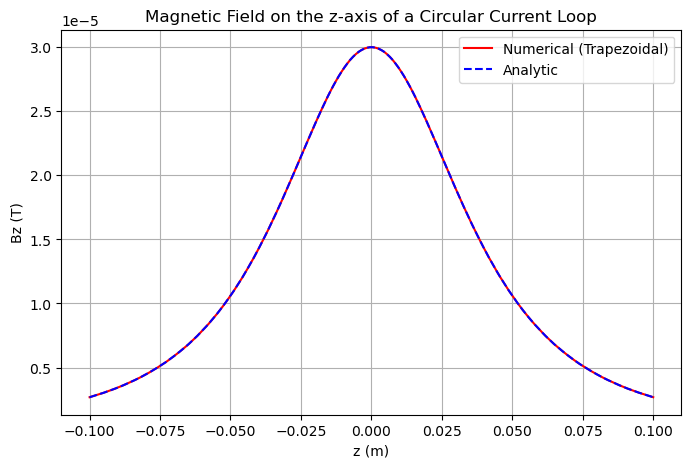

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Read the CSV file generated by the C++ code
data = pd.read_csv('Bz_data.csv')

# Extract columns
z = data['z']
Bz_numerical = data['Bz_numerical']
Bz_analytic = data['Bz_analytic']

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(z, Bz_numerical, 'r-', label='Numerical (Trapezoidal)')
plt.plot(z, Bz_analytic, 'b--', label='Analytic')
plt.xlabel('z (m)')
plt.ylabel('Bz (T)')
plt.title('Magnetic Field on the z-axis of a Circular Current Loop')
plt.legend()
plt.grid(True)
plt.show()


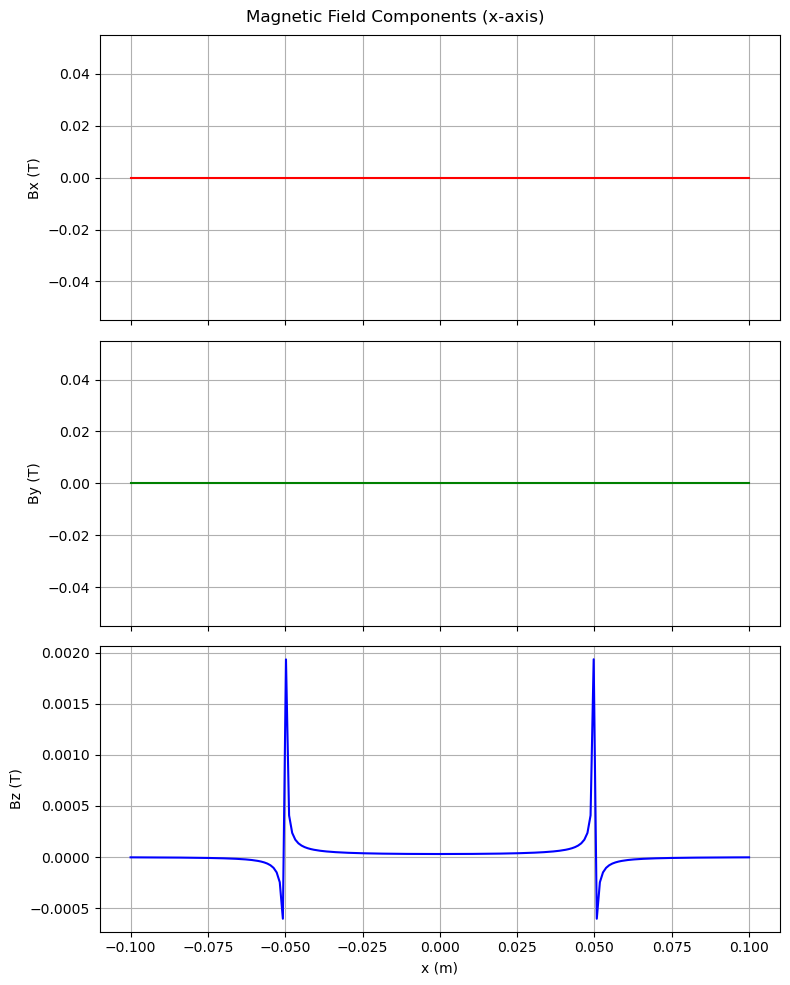

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) Load the CSV file produced by your C++ code:
filename = "BxByBz_vs_x.csv"  # or whichever CSV you have
data = pd.read_csv(filename)

# 2) Extract the columns
x_vals = data['x']
Bx_vals = data['Bx']
By_vals = data['By']
Bz_vals = data['Bz']

# 3) Create subplots in a single figure
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# --- Subplot 1: Bx vs x ---
axes[0].plot(x_vals, Bx_vals, 'r-')
axes[0].set_ylabel("Bx (T)")
axes[0].grid(True)

# --- Subplot 2: By vs x ---
axes[1].plot(x_vals, By_vals, 'g-')
axes[1].set_ylabel("By (T)")
axes[1].grid(True)

# --- Subplot 3: Bz vs x ---
axes[2].plot(x_vals, Bz_vals, 'b-')
axes[2].set_xlabel("x (m)")
axes[2].set_ylabel("Bz (T)")
axes[2].grid(True)

# 4) Add a main title
plt.suptitle("Magnetic Field Components (x-axis)")

# 5) Show the figure
plt.tight_layout()
plt.show()




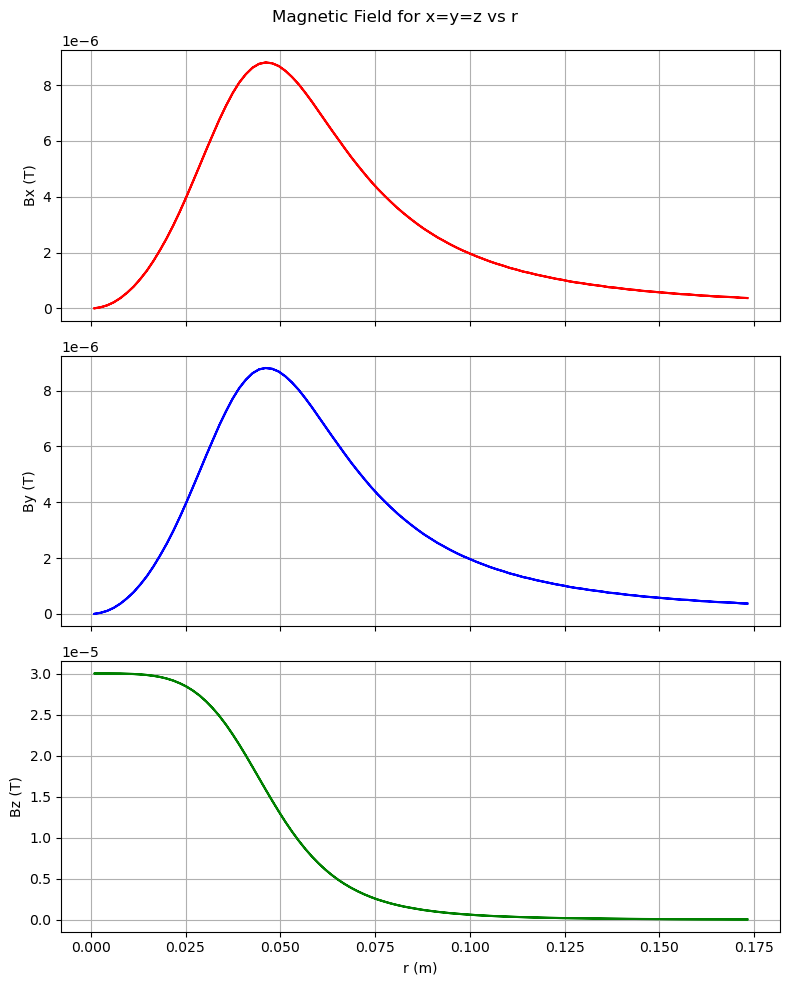

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
data = pd.read_csv("Bxyz_vs_r.csv")

# Extract columns
r_vals = data['r']
Bx_vals = data['Bx']
By_vals = data['By']
Bz_vals = data['Bz']

# Create subplots in one figure
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Subplot 1: Bx
axes[0].plot(r_vals, Bx_vals, 'r-')
axes[0].set_ylabel("Bx (T)")
axes[0].grid(True)

# Subplot 2: By
axes[1].plot(r_vals, By_vals, 'b-')
axes[1].set_ylabel("By (T)")
axes[1].grid(True)

# Subplot 3: Bz
axes[2].plot(r_vals, Bz_vals, 'g-')
axes[2].set_xlabel("r (m)")
axes[2].set_ylabel("Bz (T)")
axes[2].grid(True)

plt.suptitle("Magnetic Field for x=y=z vs r")
plt.tight_layout()
plt.show()


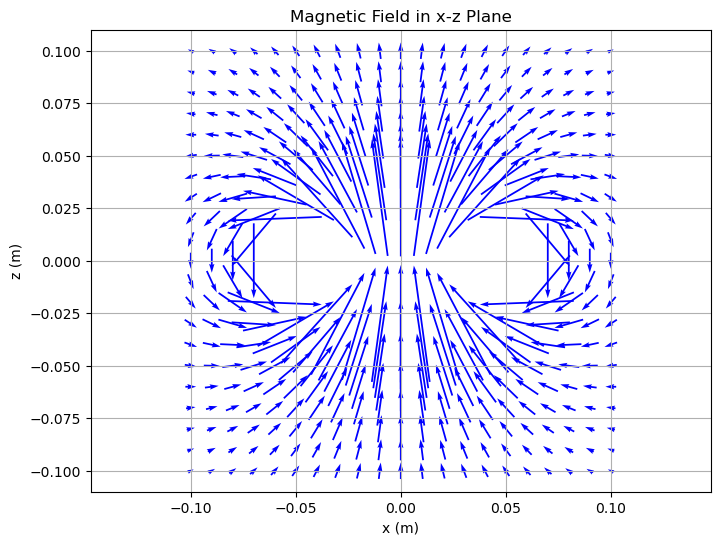

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read the CSV file generated by your C++ code
data = pd.read_csv("B_xz_plane.csv")  # or whatever your file is called

# 2) Extract columns as 1D arrays
x_vals  = data['x'].values
z_vals  = data['z'].values
Bx_vals = data['Bx'].values
By_vals = data['By'].values  # We won't use By for the quiver in x-z plane
Bz_vals = data['Bz'].values

# 3) Determine the grid size (Nx, Nz) from unique x and z
unique_x = np.unique(x_vals)
unique_z = np.unique(z_vals)
Nx = len(unique_x)
Nz = len(unique_z)

# 4) Reshape to 2D arrays so we can plot
X   = x_vals.reshape(Nx, Nz)
Z   = z_vals.reshape(Nx, Nz)
Bx2D = Bx_vals.reshape(Nx, Nz)
Bz2D = Bz_vals.reshape(Nx, Nz)

# 5) Compute the magnitude of B in the plane (sqrt(Bx^2 + Bz^2))
M = np.sqrt(Bx2D**2 + Bz2D**2)

# 6) Mask out large magnitudes
#    Choose a threshold that hides huge arrows near the wire.
threshold = 2e-5  # Example: 5e-4 T. Adjust as needed.

# Create masked copies
Bx2D_masked = Bx2D.copy()
Bz2D_masked = Bz2D.copy()

# Where magnitude is above threshold, set to NaN (which quiver won't plot)
mask = (M > threshold)
Bx2D_masked[mask] = np.nan
Bz2D_masked[mask] = np.nan

# 7) Quiver plot with masked data
plt.figure(figsize=(8,6))
plt.quiver(X, Z, Bx2D_masked, Bz2D_masked,
           pivot='mid', color='blue', scale=1e-4)

plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Magnetic Field in x-z Plane")
plt.axis('equal')  # same scale for x and z
plt.grid(True)
plt.show()

